# 11. Диффузия со скачками

**Статус:** завершено

В этой теме мы расширяем GBM скачками. Такая модель нужна, когда обычная непрерывная диффузия не объясняет резкие рыночные движения, тяжёлые хвосты доходностей и внезапные просадки.

## Модель Мертона

В модели jump-diffusion цена имеет диффузионную часть и скачки:

$$\frac{dS_t}{S_{t-}}=(\mu-\lambda k)dt+\sigma dW_t+(J-1)dN_t,$$

где $N_t$ — пуассоновский процесс интенсивности $\lambda$, $J=e^Y$ — мультипликативный скачок, $Y\sim N(m,\delta^2)$, а

$$k=\mathbb E[J-1]=e^{m+\delta^2/2}-1.$$

Компенсатор $-\lambda k$ нужен, чтобы ожидаемый темп роста не менялся просто из-за среднего скачка. Интуитивно модель говорит: большую часть времени цена движется как GBM, но иногда получает дискретный удар.

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.jump_diffusion import (
    calculate_log_returns_from_price_paths,
    calculate_maximum_drawdowns,
    plot_drawdown_distribution,
    plot_log_return_histograms,
    plot_price_paths,
    simulate_merton_jump_diffusion_price_paths,
    summarize_jump_diffusion_risk_statistics,
)

## 1. GBM против jump-diffusion

,mean_terminal_return,terminal_return_std,probability_terminal_loss_below_threshold,log_return_excess_kurtosis,mean_total_jump_count,mean_maximum_drawdown,five_percent_worst_drawdown
GBM,0.0863,0.2170,0.0755,0.0045,0.000,-0.1876,-0.3213
Jump-diffusion,0.0889,0.3293,0.1841,170.0011,1.504,-0.2526,-0.4984


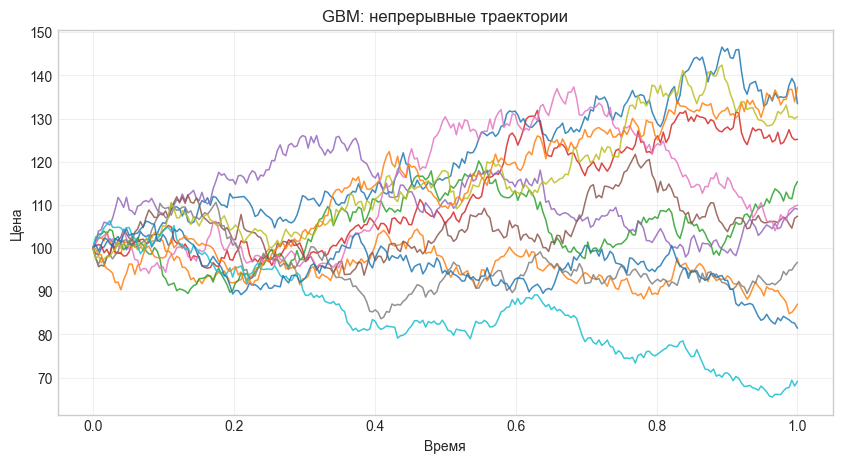

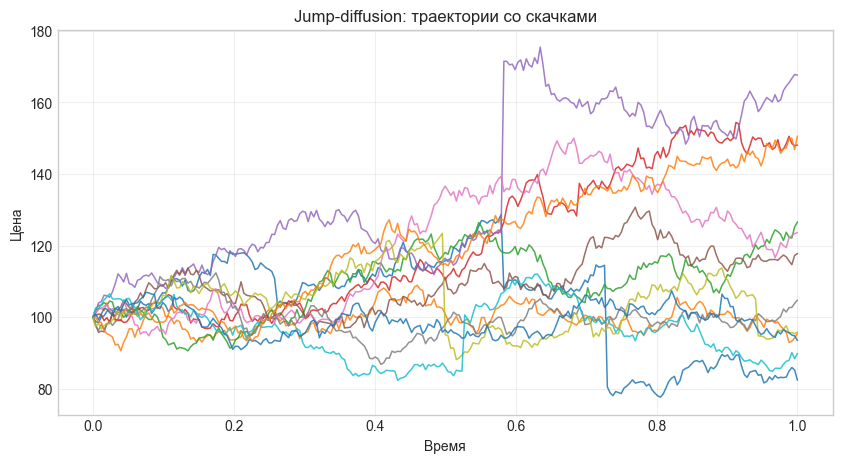

In [2]:
time_grid, gbm_paths, gbm_jump_counts = simulate_merton_jump_diffusion_price_paths(
    8000, 252, 1.0, 100.0, 0.08, 0.20, 0.0, 0.0, 0.0, True, random_seed=123
)
_, jump_paths, jump_counts = simulate_merton_jump_diffusion_price_paths(
    8000, 252, 1.0, 100.0, 0.08, 0.20, 1.5, -0.08, 0.18, True, random_seed=123
)
plot_price_paths(time_grid, gbm_paths[:12], 12, "GBM: непрерывные траектории");
plot_price_paths(time_grid, jump_paths[:12], 12, "Jump-diffusion: траектории со скачками");

pd.DataFrame([summarize_jump_diffusion_risk_statistics(gbm_paths, gbm_jump_counts, -0.20), summarize_jump_diffusion_risk_statistics(jump_paths, jump_counts, -0.20)], index=["GBM", "Jump-diffusion"])

У GBM лог-доходности почти нормальны и excess kurtosis около `0.0045`. У jump-diffusion excess kurtosis около `170`, потому что редкие скачки создают много экстремальных однодневных движений.

Средняя годовая доходность в обеих моделях близка: `0.0863` против `0.0889`, зато риск сильно отличается. Вероятность потери хуже `-20%` выросла с `0.0755` до `0.1841`, средняя максимальная просадка стала глубже: `-0.2526` против `-0.1876`. Это главный урок: одинаковое среднее не означает одинаковый хвостовой риск.

## 2. Хвосты доходностей и просадки

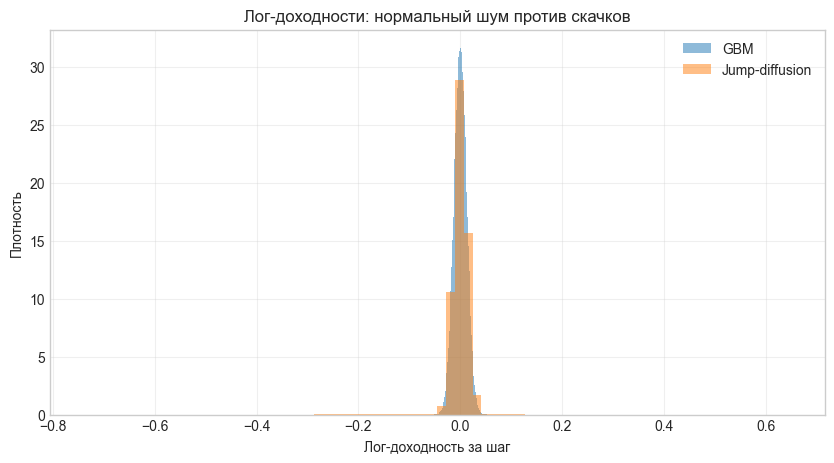

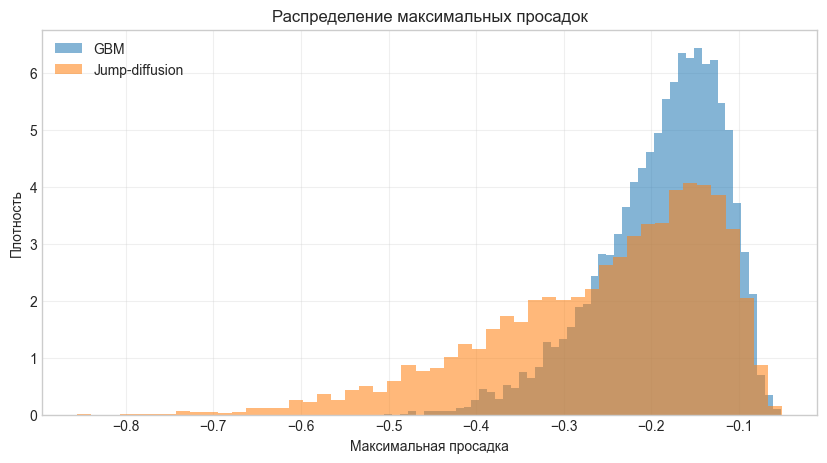

In [3]:
gbm_log_returns = calculate_log_returns_from_price_paths(gbm_paths)
jump_log_returns = calculate_log_returns_from_price_paths(jump_paths)
plot_log_return_histograms(gbm_log_returns, jump_log_returns, "Лог-доходности: нормальный шум против скачков");
plot_drawdown_distribution({"GBM": calculate_maximum_drawdowns(gbm_paths), "Jump-diffusion": calculate_maximum_drawdowns(jump_paths)}, "Распределение максимальных просадок");

На гистограмме доходностей jump-diffusion имеет острый центр и тяжёлые хвосты. Это типичная эмпирическая черта финансовых данных: большая часть дней спокойная, но редкие движения слишком велики для нормальной модели.

Просадки показывают path-dependent риск. Даже если конечная цена восстановилась, инвестор мог пережить глубокую промежуточную потерю. Поэтому для риск-менеджмента максимальная просадка часто информативнее простой дисперсии доходности.

## 3. Как интенсивность скачков меняет риск

In [4]:
rows=[]
for intensity in [0.0, 0.5, 1.5, 3.0]:
    _, paths, counts = simulate_merton_jump_diffusion_price_paths(6000,252,1,100,0.08,0.2,intensity,-0.08,0.18,True,random_seed=222)
    stats=summarize_jump_diffusion_risk_statistics(paths, counts, -0.2)
    rows.append({"lambda": intensity, **stats})
pd.DataFrame(rows)

,lambda,mean_terminal_return,terminal_return_std,probability_terminal_loss_below_threshold,log_return_excess_kurtosis,mean_total_jump_count,mean_maximum_drawdown,five_percent_worst_drawdown
0,0.0,0.0814,0.2170,0.0783,-0.0019,0.0000,-0.1883,-0.3217
1,0.5,0.0800,0.2614,0.1310,154.2962,0.5008,-0.2122,-0.4124
2,1.5,0.0814,0.3358,0.1995,173.1934,1.4843,-0.2551,-0.5102
3,3.0,0.0777,0.4161,0.2680,139.0723,3.0082,-0.3131,-0.5975


С ростом $\lambda$ растёт среднее число скачков и почти всегда ухудшаются хвостовые метрики: больше вероятность крупного убытка, сильнее просадки, выше эксцесс доходностей. В реальных задачах $\lambda$ отвечает не за обычную волатильность, а за частоту «режимных» событий: новостей, дефолтов, гэпов ликвидности.

## Выводы

1. Jump-diffusion сохраняет непрерывный шум GBM, но добавляет редкие дискретные скачки.
2. Скачки почти не обязаны менять среднюю доходность, но резко меняют хвосты.
3. Эксцесс, вероятность крупных потерь и максимальная просадка лучше показывают скачковый риск, чем одно среднее.
4. Модель Мертона полезна для опционов и риск-менеджмента, но реальная калибровка скачков требует аккуратных данных о хвостах.